In [1]:
import pandas as pd
from pathlib import Path
#import pyarrow.parquet as pq

train_path = Path(Path.cwd(), 'data', 'Zzzs_train.parquet')
train_path

WindowsPath('c:/Users/leami/Documents/3A/AML/Project_Sleep_States/data/Zzzs_train.parquet')

In [2]:
train_series = pd.read_parquet(train_path)
print(train_series.head())

      series_id  step                 timestamp     anglez    enmo  awake
0  08db4255286f     0  2018-11-05T10:00:00-0400 -30.845301  0.0447      1
1  08db4255286f     1  2018-11-05T10:00:05-0400 -34.181801  0.0443      1
2  08db4255286f     2  2018-11-05T10:00:10-0400 -33.877102  0.0483      1
3  08db4255286f     3  2018-11-05T10:00:15-0400 -34.282101  0.0680      1
4  08db4255286f     4  2018-11-05T10:00:20-0400 -34.385799  0.0768      1


In [3]:
train_series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13165560 entries, 0 to 13165559
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   series_id  object 
 1   step       uint32 
 2   timestamp  object 
 3   anglez     float32
 4   enmo       float32
 5   awake      int64  
dtypes: float32(2), int64(1), object(2), uint32(1)
memory usage: 452.0+ MB


In [4]:
train_multi_path = Path(Path.cwd(), 'data', 'Zzzs_train_multi.parquet')
train_multi_series = pd.read_parquet(train_multi_path)
train_multi_series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16289820 entries, 0 to 16289819
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   series_id  object 
 1   step       uint32 
 2   timestamp  object 
 3   anglez     float32
 4   enmo       float32
 5   awake      int64  
dtypes: float32(2), int64(1), object(2), uint32(1)
memory usage: 559.3+ MB


In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns



In [7]:
def feature_engineering(df):
    """Adds rolling mean and standard deviation for anglez and enmo."""
    df["anglez_mean"] = df["anglez"].rolling(window=10, min_periods=1).mean()
    df["anglez_std"] = df["anglez"].rolling(window=10, min_periods=1).std()
    df["enmo_mean"] = df["enmo"].rolling(window=10, min_periods=1).mean()
    df["enmo_std"] = df["enmo"].rolling(window=10, min_periods=1).std()
    
    return df

df = feature_engineering(train_multi_series)

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from tqdm import tqdm

# Función para extraer features estadísticas por ventanas con tqdm
def extract_features(df, sequence_length=50):
    features, labels = [], []
    series_ids = df['series_id'].unique()
    
    for series_id in tqdm(series_ids, desc="Procesando series"):
        sub_df = df[df['series_id'] == series_id]
        for i in range(0, len(sub_df) - sequence_length, sequence_length):
            window = sub_df.iloc[i:i+sequence_length]
            features.append([
                window['anglez'].mean(), window['anglez'].std(), window['anglez'].max(), window['anglez'].min(),
                window['enmo'].mean(), window['enmo'].std(), window['enmo'].max(), window['enmo'].min()
            ])
            labels.append(window.iloc[-1]['awake'])
    
    return np.array(features), np.array(labels)

In [9]:
train_multi_series = train_multi_series.drop(columns=['timestamp'])

In [10]:
X, y = extract_features(train_multi_series, sequence_length=50)

Procesando series: 100%|██████████| 43/43 [02:01<00:00,  2.83s/it]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Sélection automatique du device (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class CriticalPointDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).to(device)
        self.y = torch.LongTensor(y).to(device)  # Target labels should be LongTensor for CrossEntropyLoss
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class CriticalPointModel(nn.Module):
    def __init__(self, input_channels=1, hidden_dim=64, num_classes=3):
        super(CriticalPointModel, self).__init__()
        
        self.down_conv1 = nn.Conv1d(input_channels, hidden_dim, kernel_size=3, padding=1)
        self.down_conv2 = nn.Conv1d(hidden_dim, hidden_dim*2, kernel_size=3, padding=1)
        self.down_conv3 = nn.Conv1d(hidden_dim*2, hidden_dim*4, kernel_size=3, padding=1)
        
        self.max_pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.gru = nn.GRU(hidden_dim*4, hidden_dim*4, batch_first=True)
        
        self.up_conv1 = nn.ConvTranspose1d(hidden_dim*4, hidden_dim*2, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.up_conv2 = nn.ConvTranspose1d(hidden_dim*2, hidden_dim, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.up_conv3 = nn.ConvTranspose1d(hidden_dim, input_channels, kernel_size=3, padding=1)
        
        # Adjusting the output layer for multi-class classification
        self.critical_point_pred = nn.Linear(hidden_dim*4, num_classes)  # Output for 3 classes
        
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)  # Softmax activation for multi-class classification

    def forward(self, x):
        x1 = self.relu(self.down_conv1(x))
        x2 = self.max_pool(x1)
        x2 = self.relu(self.down_conv2(x2))
        x3 = self.max_pool(x2)
        x3 = self.relu(self.down_conv3(x3))
        
        x3_gru = x3.permute(0, 2, 1)
        gru_out, _ = self.gru(x3_gru)
        
        up1 = self.relu(self.up_conv1(gru_out.permute(0, 2, 1)))
        up2 = self.relu(self.up_conv2(up1))
        up3 = self.up_conv3(up2)
        
        # Use softmax on the output of the classification layer
        critical_probs = self.softmax(self.critical_point_pred(gru_out.mean(dim=1)))
        
        return {
            'reconstructed_signal': up3,
            'critical_point_probabilities': critical_probs
        }

def train_torch_model(X_train, y_train, X_val, y_val, epochs=50, batch_size=32):
    # Reshape data for 1D convolutions
    X_train = X_train.reshape(X_train.shape[0], 1, -1)
    X_val = X_val.reshape(X_val.shape[0], 1, -1)
    
    train_dataset = CriticalPointDataset(X_train, y_train)
    val_dataset = CriticalPointDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    model = CriticalPointModel(num_classes=3).to(device)  # Set num_classes=3 for 3-class classification
    criterion = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            output = model(batch_X)
            loss = criterion(output['critical_point_probabilities'], batch_y)  # No need to squeeze for CrossEntropyLoss
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        # Empty the GPU cache to prevent memory fragmentation
        torch.cuda.empty_cache()
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                output = model(batch_X)
                val_loss = criterion(output['critical_point_probabilities'], batch_y)
                val_losses.append(val_loss.item())
        
        print(f'Epoch {epoch+1}: Train Loss = {np.mean(train_losses):.4f}, Val Loss = {np.mean(val_losses):.4f}')
    
    return model

# Exemple d'utilisation
model = train_torch_model(X_train, y_train, X_test, y_test, epochs=30, batch_size=64)

# Predicting the class probabilities for X_test
predictions = model(torch.FloatTensor(X_test.reshape(X_test.shape[0], 1, -1)).to(device))['critical_point_probabilities'].cpu().detach().numpy()

# Get the predicted class labels
predicted_labels = np.argmax(predictions, axis=1)  # Convert probabilities to class labels


Using device: cuda
Epoch 1: Train Loss = 0.7996, Val Loss = 0.7934
Epoch 2: Train Loss = 0.8021, Val Loss = 0.8143
Epoch 3: Train Loss = 0.8014, Val Loss = 0.7754
Epoch 4: Train Loss = 0.7695, Val Loss = 0.7619
Epoch 5: Train Loss = 0.7661, Val Loss = 0.7609
Epoch 6: Train Loss = 0.7716, Val Loss = 0.7861
Epoch 7: Train Loss = 0.7643, Val Loss = 0.7629
Epoch 8: Train Loss = 0.7828, Val Loss = 0.7904
Epoch 9: Train Loss = 0.7829, Val Loss = 0.7820
Epoch 10: Train Loss = 0.7837, Val Loss = 0.7572
Epoch 11: Train Loss = 0.7629, Val Loss = 0.7601
Epoch 12: Train Loss = 0.7621, Val Loss = 0.7587
Epoch 13: Train Loss = 0.7638, Val Loss = 0.7824
Epoch 14: Train Loss = 0.7729, Val Loss = 0.7592
Epoch 15: Train Loss = 0.7625, Val Loss = 0.7622
Epoch 16: Train Loss = 0.7634, Val Loss = 0.7591
Epoch 17: Train Loss = 0.7623, Val Loss = 0.7566
Epoch 18: Train Loss = 0.7622, Val Loss = 0.7597
Epoch 19: Train Loss = 0.7622, Val Loss = 0.7610
Epoch 20: Train Loss = 0.7624, Val Loss = 0.7600
Epoch 21: 

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluar el modelo
accuracy = accuracy_score(y_test, predicted_labels)
print(f"Accuracy: {accuracy:.4f}")

# Reporte de clasificación
print(classification_report(y_test, predicted_labels))


Accuracy: 0.7845
              precision    recall  f1-score   support

           0       0.76      0.83      0.79     18018
           1       0.82      0.89      0.85     34609
           2       0.67      0.44      0.53     12528

    accuracy                           0.78     65155
   macro avg       0.75      0.72      0.73     65155
weighted avg       0.78      0.78      0.77     65155



In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Sélection automatique du device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class CriticalPointDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).to(device)
        self.y = torch.LongTensor(y).to(device)  # Important pour CrossEntropyLoss
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class CriticalPointModel(nn.Module):
    def __init__(self, input_channels=1, hidden_dim=128, num_classes=3):
        super(CriticalPointModel, self).__init__()
        
        self.down_conv1 = nn.Sequential(
            nn.Conv1d(input_channels, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.1)
        )
        self.down_conv2 = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim*2, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim*2),
            nn.LeakyReLU(0.1)
        )
        self.down_conv3 = nn.Sequential(
            nn.Conv1d(hidden_dim*2, hidden_dim*4, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim*4),
            nn.LeakyReLU(0.1)
        )

        self.max_pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.3)  # Dropout pour éviter l'overfitting

        # Ajout d'une couche supplémentaire dans le GRU
        self.gru = nn.GRU(hidden_dim*4, hidden_dim*4, num_layers=2, batch_first=True, dropout=0.3)
        self.layer_norm = nn.LayerNorm(hidden_dim*4)

        self.up_conv1 = nn.ConvTranspose1d(hidden_dim*4, hidden_dim*2, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.up_conv2 = nn.ConvTranspose1d(hidden_dim*2, hidden_dim, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.up_conv3 = nn.ConvTranspose1d(hidden_dim, input_channels, kernel_size=3, padding=1)

        self.critical_point_pred = nn.Linear(hidden_dim*4, num_classes)  # Logits pour 3 classes

    def forward(self, x):
        x1 = self.down_conv1(x)
        x2 = self.max_pool(x1)
        x2 = self.down_conv2(x2)
        x3 = self.max_pool(x2)
        x3 = self.down_conv3(x3)

        x3 = self.dropout(x3)  # Dropout après la convolution

        x3_gru = x3.permute(0, 2, 1)
        gru_out, _ = self.gru(x3_gru)
        gru_out = self.layer_norm(gru_out)  # Normalisation pour plus de stabilité

        up1 = self.up_conv1(gru_out.permute(0, 2, 1))
        up2 = self.up_conv2(up1)
        up3 = self.up_conv3(up2)

        critical_logits = self.critical_point_pred(gru_out.mean(dim=1))  # Logits avant softmax

        return {
            'reconstructed_signal': up3,
            'critical_point_logits': critical_logits
        }

def train_torch_model(X_train, y_train, X_val, y_val, epochs=50, batch_size=32, lr=0.0005):
    X_train = X_train.reshape(X_train.shape[0], 1, -1)
    X_val = X_val.reshape(X_val.shape[0], 1, -1)
    
    train_dataset = CriticalPointDataset(X_train, y_train)
    val_dataset = CriticalPointDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    model = CriticalPointModel(num_classes=3).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)  # AdamW avec weight decay
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            output = model(batch_X)
            loss = criterion(output['critical_point_logits'], batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        torch.cuda.empty_cache()
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                output = model(batch_X)
                val_loss = criterion(output['critical_point_logits'], batch_y)
                val_losses.append(val_loss.item())

        mean_train_loss = np.mean(train_losses)
        mean_val_loss = np.mean(val_losses)
        print(f'Epoch {epoch+1}: Train Loss = {mean_train_loss:.4f}, Val Loss = {mean_val_loss:.4f}')

        # Sauvegarde du meilleur modèle
        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            torch.save(model.state_dict(), "best_model.pth")
    
    print("Training finished. Best validation loss:", best_val_loss)
    return model

# Entraînement du modèle
model = train_torch_model(X_train, y_train, X_test, y_test, epochs=50, batch_size=64)

# Chargement du meilleur modèle
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Prédiction
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test.reshape(X_test.shape[0], 1, -1)).to(device)
    predictions_logits = model(X_test_tensor)['critical_point_logits']
    predictions = torch.softmax(predictions_logits, dim=1).cpu().numpy()

# Conversion en classes prédictes
predicted_labels = np.argmax(predictions, axis=1)
# Évaluation
accuracy = accuracy_score(y_test, predicted_labels)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, predicted_labels))


Using device: cuda
Epoch 1: Train Loss = 0.6146, Val Loss = 0.5946
Epoch 2: Train Loss = 0.5834, Val Loss = 0.5763
Epoch 3: Train Loss = 0.5734, Val Loss = 0.5610
Epoch 4: Train Loss = 0.5667, Val Loss = 0.5575
Epoch 5: Train Loss = 0.5609, Val Loss = 0.5562
Epoch 6: Train Loss = 0.5573, Val Loss = 0.5457
Epoch 7: Train Loss = 0.5542, Val Loss = 0.5417
Epoch 8: Train Loss = 0.5522, Val Loss = 0.5366
Epoch 9: Train Loss = 0.5498, Val Loss = 0.5357
Epoch 10: Train Loss = 0.5480, Val Loss = 0.5334
Epoch 11: Train Loss = 0.5453, Val Loss = 0.5387
Epoch 12: Train Loss = 0.5446, Val Loss = 0.5425
Epoch 13: Train Loss = 0.5431, Val Loss = 0.5368
Epoch 14: Train Loss = 0.5414, Val Loss = 0.5303
Epoch 15: Train Loss = 0.5400, Val Loss = 0.5310
Epoch 16: Train Loss = 0.5393, Val Loss = 0.5273
Epoch 17: Train Loss = 0.5381, Val Loss = 0.5305
Epoch 18: Train Loss = 0.5378, Val Loss = 0.5295
Epoch 19: Train Loss = 0.5364, Val Loss = 0.5301
Epoch 20: Train Loss = 0.5362, Val Loss = 0.5256
Epoch 21: 

C:\Users\leami\AppData\Local\Temp\ipykernel_17092\2632774620.py:134: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Accuracy: 0.8022
              precision    recall  f1-score   support

           0       0.78      0.87      0.82     18018
           1       0.84      0.87      0.86     34609
           2       0.69      0.51      0.58     12528

    accuracy                           0.80     65155
   macro avg       0.77      0.75      0.76     65155
weighted avg       0.80      0.80      0.80     65155



In [ ]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

In [ ]:
model_multi = lgb.LGBMClassifier()
model_multi.fit(X_train_multi, y_train_multi)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003821 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 260618, number of used features: 8
[LightGBM] [Info] Start training from score -1.285113
[LightGBM] [Info] Start training from score -0.631658
[LightGBM] [Info] Start training from score -1.651973


LGBMClassifier()

Accuracy: 0.8295
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.84     18018
           1       0.85      0.90      0.87     34609
           2       0.80      0.60      0.68     12528

    accuracy                           0.83     65155
   macro avg       0.82      0.79      0.80     65155
weighted avg       0.83      0.83      0.83     65155



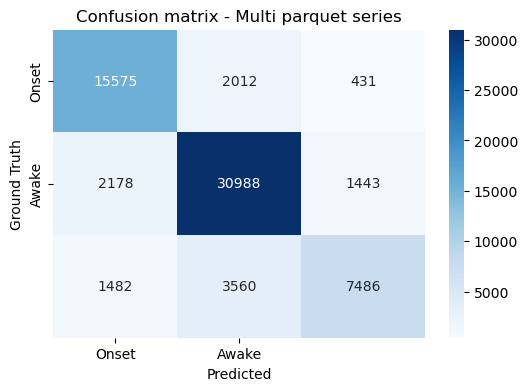

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones en el conjunto de test
y_pred_multi = model_multi.predict(X_test_multi)

# 1. Precisión (accuracy)
accuracy = accuracy_score(y_test_multi, y_pred_multi)
print(f"Accuracy: {accuracy:.4f}")

# 2. Reporte de clasificación (Precision, Recall, F1)
print("Classification Report:\n", classification_report(y_test_multi, y_pred_multi))

# 3. Matriz de confusión
conf_matrix = confusion_matrix(y_test_multi, y_pred_multi)

# 4. Visualizar la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Onset", "Awake"], yticklabels=["Onset", "Awake"])
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion matrix - Multi parquet series")
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import numpy as np

# Definir el modelo
model_multi = lgb.LGBMClassifier()

# Definir el espacio de hiperparámetros a buscar
param_dist = {
    'num_leaves': np.arange(20, 200, 10),        # Número de hojas en los árboles
    'learning_rate': np.logspace(-3, 0, 10),     # Tasa de aprendizaje (0.001 a 1)
    'n_estimators': np.arange(50, 500, 50),      # Número de árboles
    'max_depth': np.arange(3, 15, 2),            # Profundidad máxima del árbol
    'min_child_samples': np.arange(10, 100, 10), # Mínimo de muestras por hoja
    'subsample': np.linspace(0.5, 1.0, 5),       # Proporción de muestras para cada árbol
    'colsample_bytree': np.linspace(0.5, 1.0, 5) # Proporción de características por árbol
}

# Definir RandomizedSearchCV
random_search = RandomizedSearchCV(
    model_multi, param_distributions=param_dist,
    n_iter=50,  # Número de combinaciones a probar
    scoring='accuracy',  # Métrica de evaluación
    cv=3,  # Validación cruzada
    verbose=2,
    n_jobs=-1,  # Usa todos los núcleos disponibles
    random_state=42
)

# Ejecutar la búsqueda
random_search.fit(X_train, y_train)

# Mostrar los mejores parámetros encontrados
print("Mejores parámetros:", random_search.best_params_)
print("Mejor puntuación de validación:", random_search.best_score_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 138504, number of negative: 72129
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005513 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 210633, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.657561 -> initscore=0.652443
[LightGBM] [Info] Start training from score 0.652443
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [ ]:
model_multi = lgb.LGBMClassifier(
    subsample=0.625,
    num_leaves=140,
    n_estimators=400,
    min_child_samples=90,
    max_depth=13,
    learning_rate=0.21544346900318823,
    colsample_bytree=0.625
)

model_multi.fit(X_train_multi, y_train_multi)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006779 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 260618, number of used features: 8
[LightGBM] [Info] Start training from score -1.285113
[LightGBM] [Info] Start training from score -0.631658
[LightGBM] [Info] Start training from score -1.651973
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

LGBMClassifier(colsample_bytree=0.625, learning_rate=0.21544346900318823,
               max_depth=13, min_child_samples=90, n_estimators=400,
               num_leaves=140, subsample=0.625)

Accuracy: 0.8805
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.86     18018
           1       0.89      0.92      0.90     34609
           2       0.90      0.78      0.84     12528

    accuracy                           0.88     65155
   macro avg       0.88      0.86      0.87     65155
weighted avg       0.88      0.88      0.88     65155



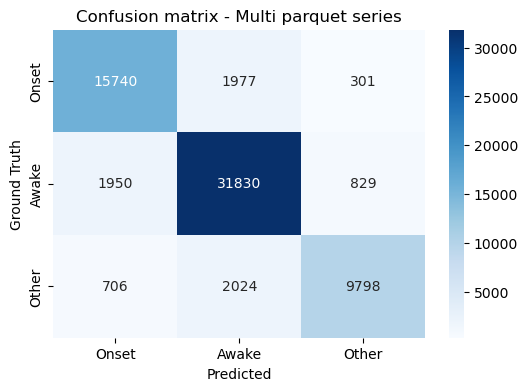

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones en el conjunto de test
y_pred_multi = model_multi.predict(X_test_multi)

# 1. Precisión (accuracy)
accuracy = accuracy_score(y_test_multi, y_pred_multi)
print(f"Accuracy: {accuracy:.4f}")

# 2. Reporte de clasificación (Precision, Recall, F1)
print("Classification Report:\n", classification_report(y_test_multi, y_pred_multi))

# 3. Matriz de confusión
conf_matrix = confusion_matrix(y_test_multi, y_pred_multi)

# 4. Visualizar la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Onset", "Awake", "Other"], yticklabels=["Onset", "Awake", "Other"])
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion matrix - Multi parquet series")
plt.show()

In [ ]:
import pandas as pd
import polars as pl

test = (pl.scan_parquet("./Data/test_series.parquet")
          .with_columns(
              (pl.col("timestamp")
                 .str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z")
                 .dt.hour()
                 .alias("hour")
              )
          )
          .drop("timestamp")
          .collect()
          .to_pandas()
)


print(test['series_id'].nunique())
print(test.head())

3
      series_id  step  anglez    enmo  hour
0  038441c925bb     0  2.6367  0.0217    15
1  038441c925bb     1  2.6368  0.0215    15
2  038441c925bb     2  2.6370  0.0216    15
3  038441c925bb     3  2.6368  0.0213    15
4  038441c925bb     4  2.6368  0.0215    15


In [ ]:
# Numero de lineas en el dataset
print(test.shape)

(450, 5)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from tqdm import tqdm

def extract_features_test(df, sequence_length=50):
    features = []
    windows_metadata = []  # Pour stocker les métadonnées de chaque fenêtre
    series_ids = df['series_id'].unique()
   
    for series_id in tqdm(series_ids, desc="Procesando series"):
        sub_df = df[df['series_id'] == series_id]
        # Si le dataframe n'est pas vide
        if not sub_df.empty:
            # Assurer que nous avons assez de données pour au moins une fenêtre
            if len(sub_df) >= sequence_length:
                for i in range(0, len(sub_df) - sequence_length + 1, sequence_length):
                    window = sub_df.iloc[i:i+sequence_length]
                    
                    # Extraire les features
                    features.append([
                        window['anglez'].mean(), window['anglez'].std(), window['anglez'].max(), window['anglez'].min(),
                        window['enmo'].mean(), window['enmo'].std(), window['enmo'].max(), window['enmo'].min()
                    ])
                    
                    # Stocker les métadonnées pour cette fenêtre
                    windows_metadata.append({
                        'series_id': series_id,
                        'start_step': window['step'].iloc[0],
                        'end_step': window['step'].iloc[-1],
                        'start_idx': i,
                        'end_idx': i + sequence_length - 1,
                        'step': window['step'].iloc[0]  # Utiliser le premier step comme identifiant
                    })
            else:
                # Pour les séries trop courtes, utiliser toutes les données disponibles
                window = sub_df
                features.append([
                    window['anglez'].mean(), window['anglez'].std(), window['anglez'].max(), window['anglez'].min(),
                    window['enmo'].mean(), window['enmo'].std(), window['enmo'].max(), window['enmo'].min()
                ])
                
                # Stocker les métadonnées
                windows_metadata.append({
                    'series_id': series_id,
                    'start_step': window['step'].iloc[0],
                    'end_step': window['step'].iloc[-1],
                    'start_idx': 0,
                    'end_idx': len(window) - 1,
                    'step': window['step'].iloc[0]  # Utiliser le premier step comme identifiant
                })
   
    # Vérification que features n'est pas vide
    if not features:
        raise ValueError("Aucune feature n'a été extraite, vérifiez vos données d'entrée.")
    
    # Créer un DataFrame condensé avec une ligne par fenêtre
    condensed_df = pd.DataFrame(windows_metadata)
    
    # Convertir les features en array NumPy
    X_test = np.array(features)
        
    return X_test, condensed_df

# Exemple d'utilisation
# df_test = feature_engineering(test)
# X_test, df_test_selected = extract_features_test(df_test, sequence_length=30)
# y_pred = model_multi.predict(X_test)
# y_pred_proba = model_multi.predict_proba(X_test)

In [ ]:
df_test = feature_engineering(test)
df_test.drop(columns=['hour'])
X_test, df_test_selected = extract_features_test(df_test, sequence_length=50)
y_pred = model_multi.predict(X_test)

print(f"Number of series in df_test_selected: {df_test_selected['series_id'].nunique()}")  # Imprimer le nombre de séries dans 

Procesando series: 100%|██████████| 3/3 [00:00<00:00, 598.62it/s]

Number of series in df_test_selected: 3


In [ ]:
# Obtenir les prédictions brutes
test = df_test_selected.copy()
y_pred_proba = model_multi.predict_proba(X_test)
test['sleep_prob'] = y_pred_proba[:, 0]  # Probabilité de classe 0 (sommeil)
test['awake_prob'] = y_pred_proba[:, 1]  # Probabilité de classe 1 (éveil)

print(f"Nombre de séries dans test: {test['series_id'].nunique()}")
print(f"Nombre de lignes dans test: {len(test)}")

# Libérer la mémoire
del y_pred_proba

# Initialiser la liste pour stocker les événements
events = []

# Paramètres pour ajuster la détection (pas besoin de SLEEP_THRESHOLD ici)
# On va calculer la moyenne de sleep_prob pour chaque série
for series_id, group in test.groupby('series_id'):
    group = group.sort_values('step')
    print(f"Nombre de lignes pour {series_id} avant filtrage : {group.shape[0]}")

    # Calculer la moyenne de sleep_prob pour la série
    mean_sleep_prob = group['sleep_prob'].mean()
    print(f"Moyenne de sleep_prob pour la série {series_id}: {mean_sleep_prob}")
    
    # Déterminer les états (sommeil/éveil) en fonction de la moyenne de sleep_prob
    is_sleep = group['sleep_prob'] > mean_sleep_prob  # Utilisation de la moyenne comme seuil
    
    if is_sleep.any():  # Vérifie si au moins un événement de sommeil est trouvé
        print(f"Il y a des périodes de sommeil pour {series_id} avec la moyenne comme seuil")

    # Pour chaque ligne qui correspond à un début de sommeil
    for idx, row in group[is_sleep].iterrows():
        # Vérifier si cette ligne représente un début de période de sommeil
        # On peut utiliser start_step et end_step qui sont déjà dans notre DataFrame condensé
        
        # Ajouter l'événement onset
        events.append({
            'series_id': series_id,
            'step': row['start_step'],
            'event': 'onset',
            'score': row['sleep_prob']
        })
        
        # Ajouter l'événement wakeup
        events.append({
            'series_id': series_id,
            'step': row['end_step'],
            'event': 'wakeup',
            'score': 1 - row['sleep_prob']
        })

# Créer le DataFrame de soumission
submission = pd.DataFrame(events)

# Afficher les statistiques
print(f"Total events detected: {len(submission)}")
print(f"Onset events: {(submission['event'] == 'onset').sum()}")
print(f"Wakeup events: {(submission['event'] == 'wakeup').sum()}")
print(f"Unique series: {submission['series_id'].nunique()}")
print(f"Average events per series: {len(submission)/submission['series_id'].nunique():.1f}")

# Finaliser le format de soumission
submission = submission.reset_index(drop=True).reset_index(names="row_id")

# Sauvegarder la soumission
submission.to_csv('submission_lgbm_simplified.csv', index=False)

# Afficher un échantillon du fichier de soumission
print("\nSample of submission file:")
print(submission.head(20))


Nombre de séries dans test: 3
Nombre de lignes dans test: 9
Nombre de lignes pour 038441c925bb avant filtrage : 3
Moyenne de sleep_prob pour la série 038441c925bb: 0.8002554950378444
Il y a des périodes de sommeil pour 038441c925bb avec la moyenne comme seuil
Nombre de lignes pour 03d92c9f6f8a avant filtrage : 3
Moyenne de sleep_prob pour la série 03d92c9f6f8a: 0.1317637055342322
Il y a des périodes de sommeil pour 03d92c9f6f8a avec la moyenne comme seuil
Nombre de lignes pour 0402a003dae9 avant filtrage : 3
Moyenne de sleep_prob pour la série 0402a003dae9: 3.343993719967171e-05
Il y a des périodes de sommeil pour 0402a003dae9 avec la moyenne comme seuil
Total events detected: 10
Onset events: 5
Wakeup events: 5
Unique series: 3
Average events per series: 3.3

Sample of submission file:
   row_id     series_id  step   event     score
0       0  038441c925bb    50   onset  0.854193
1       1  038441c925bb    99  wakeup  0.145807
2       2  038441c925bb   100   onset  0.871475
3       3 